In [1]:
pip install pandas matplotlib prophet requests

In [2]:
import requests
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [3]:
# STEP 1: Fetch Bitcoin Data
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=365"

response = requests.get(url)

data = response.json()

In [4]:
# STEP 2: Convert JSON to DataFrame
prices = data["prices"]

df = pd.DataFrame(prices, columns=["ds", "y"])

# Convert timestamp to date
df["ds"] = pd.to_datetime(df["ds"], unit='ms')

# Keep only date part
df["ds"] = df["ds"].dt.date

# Convert again into datetime
df["ds"] = pd.to_datetime(df["ds"])

print(df.head())

          ds              y
0 2025-05-14  104184.490393
1 2025-05-15  103594.425751
2 2025-05-16  103708.851364
3 2025-05-17  103556.034940
4 2025-05-18  103212.364839


In [5]:
# STEP 3: Train Prophet Model
model = Prophet()

model.fit(df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [6]:
# STEP 4: Future Prediction
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

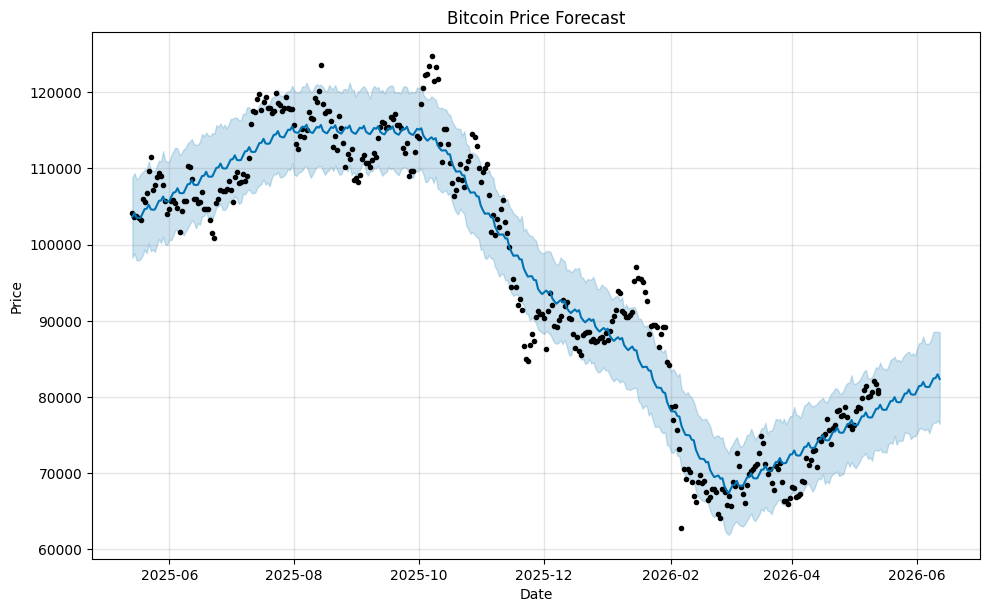

In [7]:
# STEP 5: Show Forecast Graph
model.plot(forecast)

plt.title("Bitcoin Price Forecast")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [8]:
# STEP 6: Show Forecast Data
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail())

            ds          yhat    yhat_lower    yhat_upper
390 2026-06-08  81899.621121  76158.099553  87630.396957
391 2026-06-09  82440.558813  76661.814576  88548.089796
392 2026-06-10  82476.212664  76609.447181  88578.009539
393 2026-06-11  82978.455714  76934.143963  88561.320442
394 2026-06-12  82360.709515  76471.478508  88493.185915
